# Qiskit Basics: Statevectors, Measurement, Superposition, and Entanglement

Author: Frank Chuang, NCCU

This notebook introduces the first concepts students need before learning quantum algorithms.

We focus on four ideas:

1. **Statevector**: the exact quantum state before measurement, such as $|\psi\rangle$.
2. **Measurement**: converting a quantum state into classical bits.
3. **Superposition**: using the $H$ gate to create probabilistic outcomes.
4. **Entanglement**: using $H + CX$ to create a Bell state.

## 1. Import Qiskit tools

We use two approaches to simulate quantum circuits:

- `Statevector`: shows the exact mathematical quantum state **before measurement**, for example $|\psi\rangle$.
- `AerSimulator`: runs the circuit many times and gives measurement counts, similar to a real quantum experiment.

In [1]:
# Main Qiskit tools
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram

# AerSimulator is a classical simulator that mimics repeated quantum measurements.
from qiskit_aer import AerSimulator

## 2. Helper functions

In [2]:
def get_statevector(qc):
    """
    Return the exact statevector of a circuit before measurement.

    Use this only for circuits without measurement.
    """

    return Statevector.from_instruction(qc)


def create_measured_circuit(qc):
    """
    Create a new circuit that copies qc and performs measurement.

    Why create a new circuit?
    - For teaching, it is cleaner to keep the original state-preparation circuit unchanged.
    - Then we can inspect the statevector first and measure later.

    What does compose() do?
    - compose() copies the gates from qc into measured_qc.
    """

    num_qubits = qc.num_qubits

    # Create a new circuit with the same number of qubits and classical bits.
    # Classical bits are needed to store measurement results.
    measured_qc = QuantumCircuit(num_qubits, num_qubits)

    # Copy all gates from qc into measured_qc.
    measured_qc.compose(qc, inplace=True)

    # Measure every qubit and store each result in the classical bit with the same index.
    # Example: qubit 0 -> classical bit 0, qubit 1 -> classical bit 1.
    measured_qc.measure(range(num_qubits), range(num_qubits))

    return measured_qc


def run_sampling_circuit(qc, shots=1024):
    """
    Run a measured circuit many times and return measurement counts.

    shots = number of repetitions.

    Quantum measurement is probabilistic, so one run is not enough.

    Repeating the experiment many times lets us estimate the probability distribution.
    """

    simulator = AerSimulator()

    # transpile() rewrites the circuit into a form suitable for the simulator/backend.
    compiled_qc = transpile(qc, simulator)

    # Run the circuit repeatedly.
    result = simulator.run(compiled_qc, shots=shots).result()

    # Return results such as {'0': 512, '1': 512}.
    return result.get_counts()

## 3. Single-qubit initial state

A new qubit starts in the computational basis state $|0\rangle$.

In vector form:

$$
|0\rangle = \begin{bmatrix} 1 \\ 0 \end{bmatrix}
$$

This means:

$$
P(0) = 1, \qquad P(1) = 0
$$

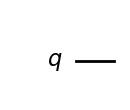

In [3]:
# Create a quantum circuit with 1 qubit and 0 classical bits.
qc = QuantumCircuit(1)

# Draw the circuit.
qc.draw("mpl")

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


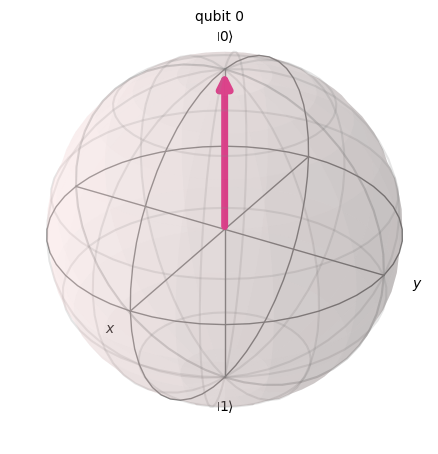

In [4]:
# Get the exact mathematical state of the circuit.
state = get_statevector(qc)
print(state)

# Visualize the state on the Bloch sphere.
plot_bloch_multivector(state)

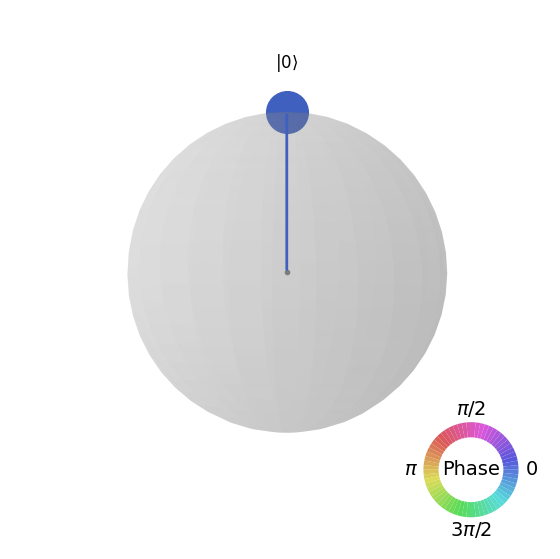

In [5]:
# QSphere works well for one or more qubits.
qsphere = state.draw("qsphere")
qsphere

## 4. $X$ gate: bit flip

The $X$ gate is the quantum version of a classical NOT gate.

It flips the computational basis states:

$$
X|0\rangle = |1\rangle
$$

$$
X|1\rangle = |0\rangle
$$

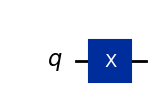

In [6]:
# Create a fresh one-qubit circuit.
qc = QuantumCircuit(1)

# Apply X gate to qubit 0.
qc.x(0)

# Draw the circuit.
qc.draw("mpl")

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


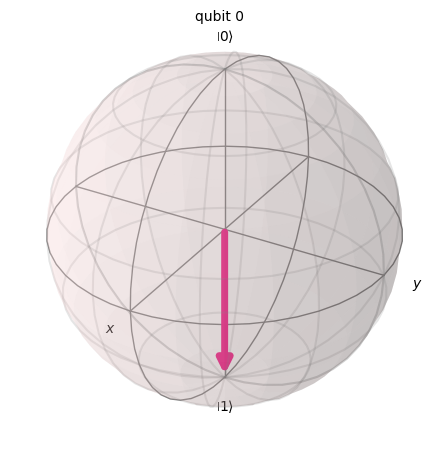

In [7]:
# After X is applied to |0⟩, the state becomes |1⟩.
state = get_statevector(qc)
print(state)
plot_bloch_multivector(state)

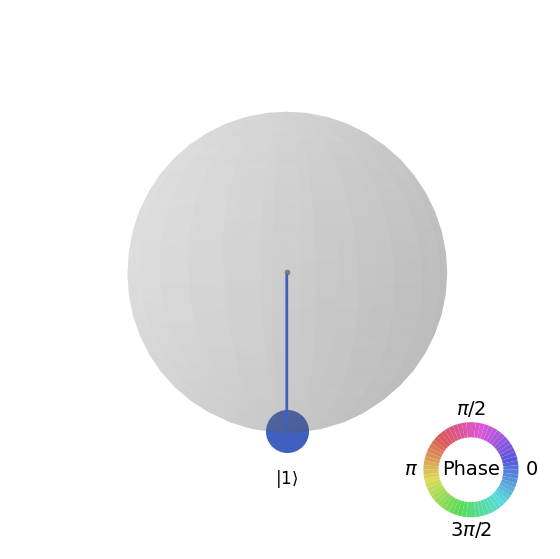

In [8]:
# Draw QSphere.
qsphere = state.draw("qsphere")
qsphere

## 5. Measurement: from quantum to classical

Measurement converts a quantum state into a classical bit.

For example:

- If the qubit is $|0\rangle$, measuring gives the classical result $0$.
- If the qubit is $|1\rangle$, measuring gives the classical result $1$.

A measured circuit needs classical bits because the measurement result must be stored somewhere.

For a general qubit,

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle,
$$

where

$$
\alpha, \beta \in \mathbb{C}, \qquad |\alpha|^2 + |\beta|^2 = 1.
$$

The measurement probabilities are:

$$
P(0) = |\alpha|^2, \qquad P(1) = |\beta|^2.
$$

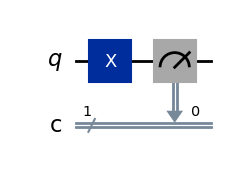

In [9]:
# Create a measured version of the circuit.
# The original qc only prepares the state.
# measured_qc copies qc and performs measurement.
measured_qc = create_measured_circuit(qc)
measured_qc.draw("mpl")

{'1': 1024}


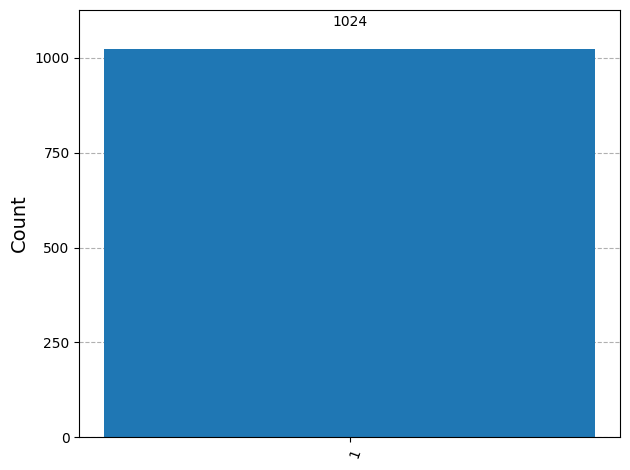

In [10]:
# Run the measured circuit many times.
# Because the state is definitely |1⟩, all results should be 1.
counts = run_sampling_circuit(measured_qc, shots=1024)
print(counts)
plot_histogram(counts)

## 6. $H$ gate: superposition

The $H$ gate creates superposition.

Starting from $|0\rangle$, the $H$ gate creates:

$$
H|0\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle + |1\rangle\right)
$$

Therefore, the measurement probabilities are:

$$
P(0) = \frac{1}{2}, \qquad P(1) = \frac{1}{2}.
$$

Important: before measurement, the qubit is not simply “$0$ or $1$”. It is in a quantum state with both basis components.

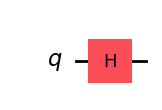

In [11]:
# Create a fresh one-qubit circuit.
qc = QuantumCircuit(1)

# Apply H gate to qubit 0.
# This creates superposition from |0⟩.
qc.h(0)

qc.draw("mpl")

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


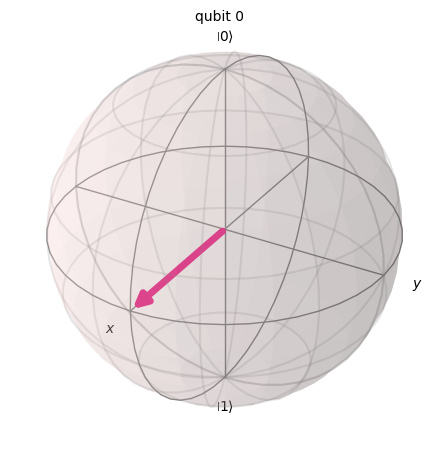

In [12]:
# Inspect the exact state before measurement.
state = get_statevector(qc)
print(state)
plot_bloch_multivector(state)

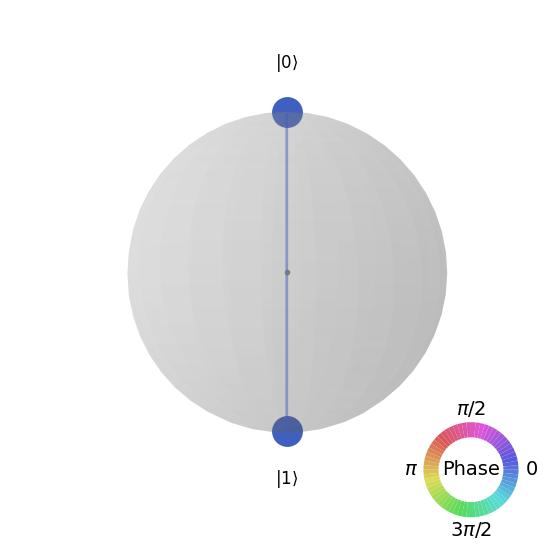

In [13]:
# Draw QSphere.
qsphere = state.draw("qsphere")
qsphere

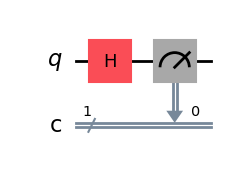

In [14]:
# Add measurement to the H circuit.
measured_qc = create_measured_circuit(qc)
measured_qc.draw("mpl")

{'1': 498, '0': 526}


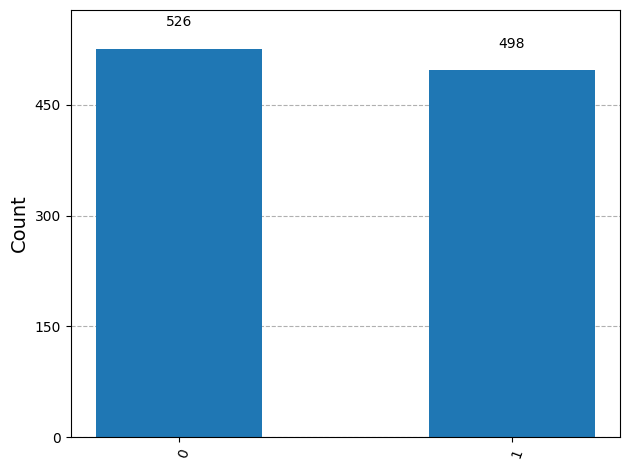

In [15]:
# Run the circuit many times.
# The counts should be approximately half 0 and half 1.
# It will not be exactly 50/50 because sampling has randomness.
counts = run_sampling_circuit(measured_qc, shots=1024)
print(counts)
plot_histogram(counts)

## 7. $X$ followed by $H$

This section shows that gate order matters.

Steps:

1. Start from $|0\rangle$.
2. Apply $X$: $|0\rangle \mapsto |1\rangle$.
3. Apply $H$ to $|1\rangle$.

The result is still a superposition, but with a negative relative phase:

$$
H|1\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle - |1\rangle\right)
$$

Measurement still gives approximately:

$$
P(0) = \frac{1}{2}, \qquad P(1) = \frac{1}{2}.
$$

The negative sign is invisible in this simple measurement, but it becomes important in interference and quantum algorithms.

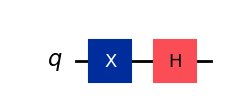

In [16]:
# Create a fresh one-qubit circuit.
qc = QuantumCircuit(1)

# First flip |0⟩ to |1⟩.
qc.x(0)

# Then apply H.
qc.h(0)

qc.draw("mpl")

Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


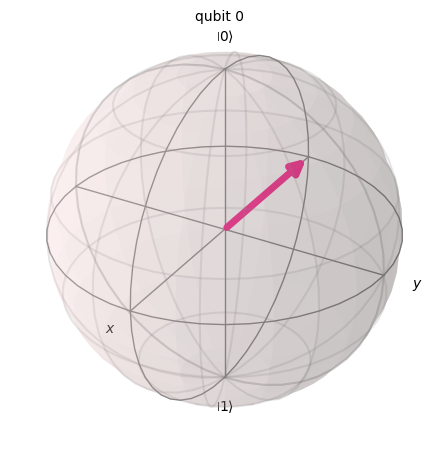

In [17]:
# Inspect the exact state before measurement.
state = get_statevector(qc)
print(state)
plot_bloch_multivector(state)

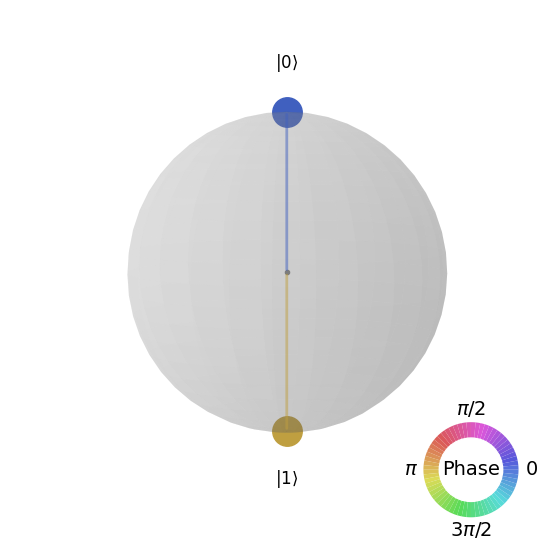

In [18]:
# Draw QSphere.
qsphere = state.draw("qsphere")
qsphere

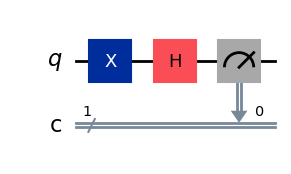

In [19]:
# Add measurement and run the circuit.
measured_qc = create_measured_circuit(qc)
measured_qc.draw("mpl")

{'0': 508, '1': 516}


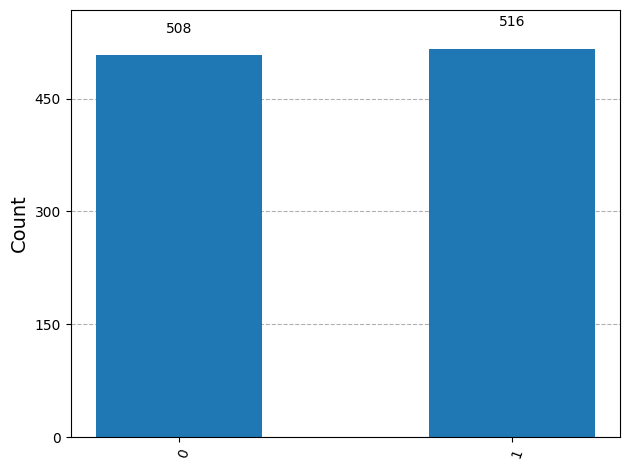

In [20]:
# Measurement probabilities are still approximately 50/50.
counts = run_sampling_circuit(measured_qc, shots=1024)
print(counts)
plot_histogram(counts)

## 8. Important Note: Dirac Notation vs. Qiskit Bit Ordering

This notebook uses **Dirac notation** as the main bit ordering convention:

$$
|q_0 q_1\rangle
$$

So in the mathematical explanation:

- the first bit is qubit $0$
- the second bit is qubit $1$

However, Qiskit often displays state labels and measurement strings in the order:

$$
|q_1 q_0\rangle
$$

This means:

- the **rightmost** bit corresponds to qubit $0$
- the **leftmost** bit corresponds to qubit $1$

For example, in a two-qubit Qiskit output:

- `"00"` means qubit $1 = 0$ and qubit $0 = 0$
- `"11"` means qubit $1 = 1$ and qubit $0 = 1$
- `"10"` means qubit $1 = 1$ and qubit $0 = 0$
- `"01"` means qubit $1 = 0$ and qubit $0 = 1$

### Bit Ordering Rule

Use this rule in class:

> Dirac notation explains the **mathematical meaning**.  
> Qiskit output shows the **software display convention**.

Do not mix them unconsciously. That is the whole trap.



## 9. Two independent qubits in superposition

Now we use two qubits. Their initial state is:

$$
|00\rangle = |0\rangle \otimes |0\rangle.
$$

If we apply an $H$ gate to both qubits, each qubit becomes:

$$
H|0\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle + |1\rangle\right).
$$

The combined state is the tensor product of the two qubits:

$$
(H \otimes H)|00\rangle
= \left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right)
\otimes
\left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right)
$$

$$
= \frac{1}{2}\left(|00\rangle + |01\rangle + |10\rangle + |11\rangle\right).
$$

### Result

We obtain an equal superposition of four states:

$$
|00\rangle,\quad |01\rangle,\quad |10\rangle,\quad |11\rangle.
$$

Each state has probability:

$$
\left|\frac{1}{2}\right|^2 = \frac{1}{4} = 25\%.
$$

### Important: this is **not** entanglement

The two qubits are **independent**:

- Each qubit is in superposition.
- There is **no correlation** between them.
- Measuring one qubit does **not** determine the other.

Mathematically, this state is separable because it can be written as a tensor product:

$$
|\psi\rangle = |\psi_0\rangle \otimes |\psi_1\rangle.
$$

### Contrast with entanglement

For example, the Bell state is:

$$
|\Phi^+\rangle = \frac{1}{\sqrt{2}}\left(|00\rangle + |11\rangle\right).
$$

In this case:

- Only two outcomes are possible: $00$ or $11$.
- Measuring one qubit determines the other.

That is **entanglement**.

> Superposition creates possibilities.  
> Entanglement creates correlations.

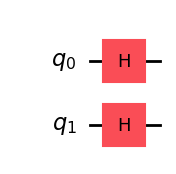

In [21]:
# Create a circuit with 2 qubits and no classical bits first.
qc = QuantumCircuit(2)

# Apply H to both qubits.
qc.h(0)
qc.h(1)

qc.draw("mpl")

In [22]:
# Inspect the exact two-qubit state before measurement.
state = get_statevector(qc)
print(state)

Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))


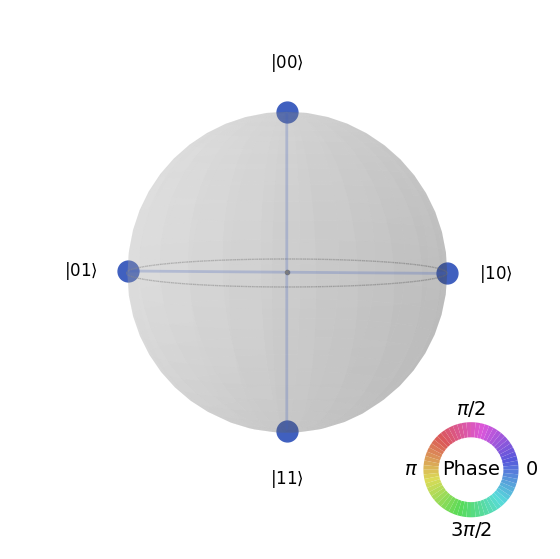

In [23]:
# Draw QSphere.
qsphere = state.draw("qsphere")
qsphere

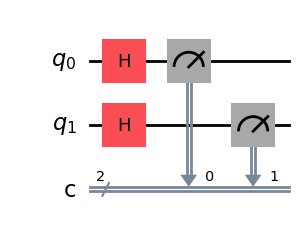

In [24]:
# Add measurement and run the circuit.
measured_qc = create_measured_circuit(qc)
measured_qc.draw("mpl")

{'10': 264, '01': 257, '00': 248, '11': 255}


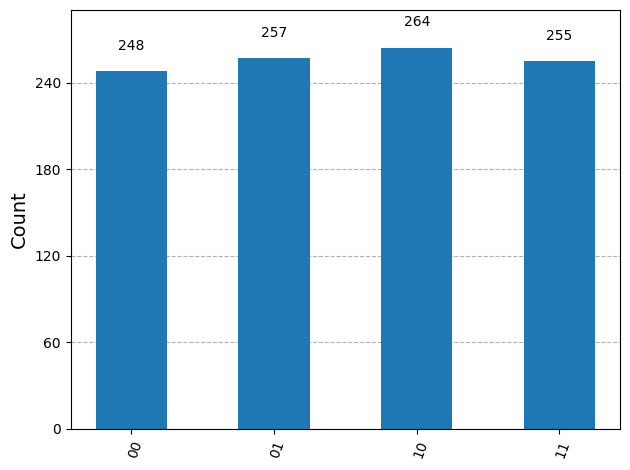

In [25]:
# We expect about four equally likely outcomes.
counts = run_sampling_circuit(measured_qc, shots=1024)
print(counts)
plot_histogram(counts)

## 10. Bell State: Two-Qubit Entanglement

Now we create one of the most important quantum states: a **Bell state**.

A Bell state is a simple example of **entanglement**.  
Entanglement means that two qubits cannot be understood as two separate, independent qubits anymore.  
Instead, they must be understood as one combined quantum system.

The key idea is:

> The result of one qubit is connected to the result of the other qubit.

---

### Step 1: Start from `|00⟩`

We begin with two qubits:

$$
|00\rangle = |0\rangle \otimes |0\rangle
$$

Using our Dirac convention:

$$
|00\rangle = |0\rangle_{q_0} \otimes |0\rangle_{q_1}
$$

This means:

- qubit $0$ is in state $|0\rangle$
- qubit $1$ is in state $|0\rangle$

---

### Step 2: Apply `H` to qubit 0

We apply the Hadamard gate only to qubit $0$.

Since this is a two-qubit system, we describe the operation on both qubits:

$$
H \otimes I
$$

Here:

- $H$ acts on qubit $0$
- $I$ acts on qubit $1$
- $I$ is the identity operator, meaning “do nothing”

So:

> $H \otimes I$ means: apply $H$ to the first qubit and apply $I$ to the second qubit.

This is not a time sequence.  
It does **not** mean “do $H$ first and then do $I$.”  
It means each operator acts on its own qubit inside the same two-qubit system.

---

### Tensor Product Operator Rule

For a two-qubit product state, we use the tensor product rule:

$$
(A \otimes B)(|\psi\rangle \otimes |\phi\rangle)
=
(A|\psi\rangle) \otimes (B|\phi\rangle)
$$

In our case:

$$
(H \otimes I)(|\psi\rangle \otimes |\phi\rangle)
=
(H|\psi\rangle) \otimes (I|\phi\rangle)
$$

This means:

> each operator acts only on its own part of the system.

---

### Apply the Rule to `|00⟩`

We start from:

$$
|00\rangle = |0\rangle_{q_0} \otimes |0\rangle_{q_1}
$$

Apply $H \otimes I$:

$$
(H \otimes I)(|0\rangle \otimes |0\rangle)
$$

Using the tensor product rule:

$$
=
(H|0\rangle) \otimes (I|0\rangle)
$$

Now use:

$$
H|0\rangle
=
\frac{1}{\sqrt{2}}
\left(
|0\rangle + |1\rangle
\right)
$$

and:

$$
I|0\rangle = |0\rangle
$$

So:

$$
(H|0\rangle) \otimes (I|0\rangle)
=
\frac{1}{\sqrt{2}}
\left(
|0\rangle + |1\rangle
\right)
\otimes
|0\rangle
$$

Now distribute the tensor product:

$$
=
\frac{1}{\sqrt{2}}
\left(
|0\rangle \otimes |0\rangle
+
|1\rangle \otimes |0\rangle
\right)
$$

Convert back to two-qubit Dirac notation:

$$
|0\rangle \otimes |0\rangle = |00\rangle
$$

and:

$$
|1\rangle \otimes |0\rangle = |10\rangle
$$

Therefore:

$$
|00\rangle
\xrightarrow{H \otimes I}
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |10\rangle
\right)
$$

---

### What Does This State Mean?

After applying $H$ to qubit $0$, the state becomes:

$$
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |10\rangle
\right)
$$

This means the system is in a superposition of:

- $|00\rangle$
- $|10\rangle$

Notice that qubit $1$ is always $0$:

- in $|00\rangle$, qubit $1$ is $0$
- in $|10\rangle$, qubit $1$ is also $0$

So only qubit $0$ is in superposition.  
Qubit $1$ is still fixed at $|0\rangle$.

This state can still be written as:

$$
\left(
\frac{1}{\sqrt{2}}
\left(
|0\rangle + |1\rangle
\right)
\right)
\otimes
|0\rangle
$$

So this is **not entanglement yet**.

It is only:

> qubit $0$ in superposition, while qubit $1$ stays unchanged.

---

### Step 3: Apply `CX`

Now we apply the `CX` gate.

The `CX` gate is also called the **controlled-NOT gate**.

It has:

- control qubit: qubit $0$
- target qubit: qubit $1$

The rule is:

> If the control qubit is `0`, do nothing.  
> If the control qubit is `1`, flip the target qubit.

Flipping means:

$$
|0\rangle \leftrightarrow |1\rangle
$$

So the `CX` gate acts as follows:

$$
CX|00\rangle = |00\rangle
$$

because the control qubit is $0$, so the target qubit does not change.

Also:

$$
CX|10\rangle = |11\rangle
$$

because the control qubit is $1$, so the target qubit flips from $0$ to $1$.

---

### Apply `CX` to the Superposition

Before applying `CX`, the state is:

$$
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |10\rangle
\right)
$$

Now apply `CX`:

$$
CX
\left[
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |10\rangle
\right)
\right]
$$

Quantum gates are linear operators, so we can apply `CX` to each term separately:

$$
=
\frac{1}{\sqrt{2}}
\left(
CX|00\rangle + CX|10\rangle
\right)
$$

Now substitute the results:

$$
=
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |11\rangle
\right)
$$

Therefore:

$$
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |10\rangle
\right)
\xrightarrow{CX}
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |11\rangle
\right)
$$

---

### The Bell State

The final state is:

$$
|\Phi^+\rangle
=
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |11\rangle
\right)
$$

This is called the Bell state $|\Phi^+\rangle$.

It is one of the four standard Bell states.

---

### Why Is This Entangled?

The state:

$$
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |10\rangle
\right)
$$

was not entangled because it could be separated:

$$
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |10\rangle
\right)
=
\left(
\frac{1}{\sqrt{2}}
(|0\rangle + |1\rangle)
\right)
\otimes
|0\rangle
$$

This means:

- qubit $0$ has its own state
- qubit $1$ has its own state

But the Bell state:

$$
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |11\rangle
\right)
$$

cannot be separated into:

$$
(\text{state of qubit 0})
\otimes
(\text{state of qubit 1})
$$

That is why it is entangled.

In simple terms:

> The two qubits no longer have independent states.

They share one combined two-qubit state.

---

### Step 4: Measurement

The Bell state is:

$$
|\Phi^+\rangle
=
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |11\rangle
\right)
$$

The amplitude of $|00\rangle$ is:

$$
\frac{1}{\sqrt{2}}
$$

So the probability of measuring $00$ is:

$$
P(00)
=
\left|
\frac{1}{\sqrt{2}}
\right|^2
=
\frac{1}{2}
$$

The amplitude of $|11\rangle$ is also:

$$
\frac{1}{\sqrt{2}}
$$

So:

$$
P(11)
=
\left|
\frac{1}{\sqrt{2}}
\right|^2
=
\frac{1}{2}
$$

There is no $|01\rangle$ term, so:

$$
P(01)=0
$$

There is no $|10\rangle$ term, so:

$$
P(10)=0
$$

Therefore:

$$
P(00)=\frac{1}{2},
\qquad
P(11)=\frac{1}{2},
\qquad
P(01)=P(10)=0
$$

---

### Plain English Explanation

Before measurement, the system is:

$$
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |11\rangle
\right)
$$

This means the two-qubit system is in a superposition of two possibilities:

- both qubits are `0`
- both qubits are `1`

When we measure:

- if qubit $0$ is measured as `0`, qubit $1$ will also be `0`
- if qubit $0$ is measured as `1`, qubit $1$ will also be `1`

So the two qubits are perfectly correlated.

---

### Key Ideas

This is not ordinary independent randomness.

It is not:

> qubit $0$ randomly becomes `0` or `1`, and qubit $1$ independently becomes `0` or `1`.

Instead, it is:

> the whole two-qubit system randomly becomes either `00` or `11`.

The randomness belongs to the whole system, not to each qubit separately. That is the basic idea of entanglement.

Superposition means:

> one quantum system can be in a combination of possible states.

Entanglement means:

> multiple quantum systems share one combined state, so their measurement results are connected.

In this example:

$$
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |10\rangle
\right)
$$

is **not entangled**, because it can be separated as:

$$
\left(
\frac{1}{\sqrt{2}}
(|0\rangle + |1\rangle)
\right)
\otimes
|0\rangle
$$

But:

$$
\frac{1}{\sqrt{2}}
\left(
|00\rangle + |11\rangle
\right)
$$

is **entangled**, because it cannot be separated into:

$$
(\text{state of qubit 0})
\otimes
(\text{state of qubit 1})
$$

> The Hadamard gate creates superposition, and the CX gate turns that superposition into correlation.  
> That correlation is entanglement.

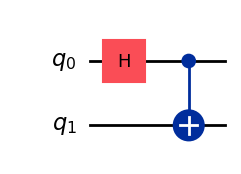

In [26]:
# Create a two-qubit circuit.
qc = QuantumCircuit(2)

# Step 1: put qubit 0 into superposition.
qc.h(0)

# Step 2: entangle qubit 0 and qubit 1.
# qubit 0 = control
# qubit 1 = target
qc.cx(0, 1)

qc.draw("mpl")

In [27]:
# Inspect the exact Bell state before measurement.
state = get_statevector(qc)
print(state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


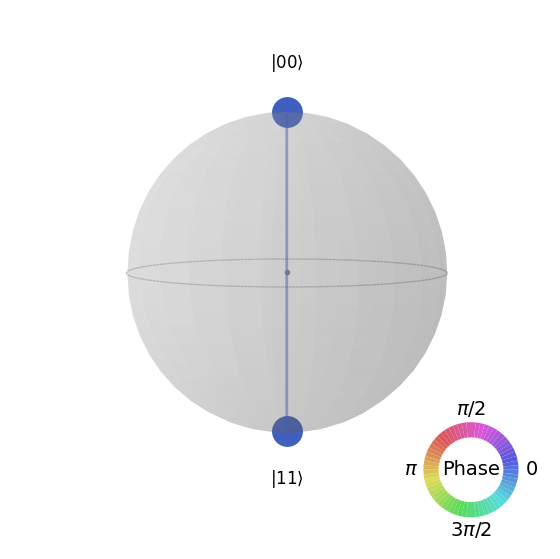

In [28]:
# Draw QSphere.
qsphere = state.draw("qsphere")
qsphere

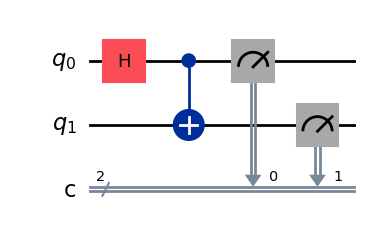

In [29]:
# Add measurement and run the Bell-state circuit.
measured_qc = create_measured_circuit(qc)
measured_qc.draw("mpl")

{'00': 527, '11': 497}


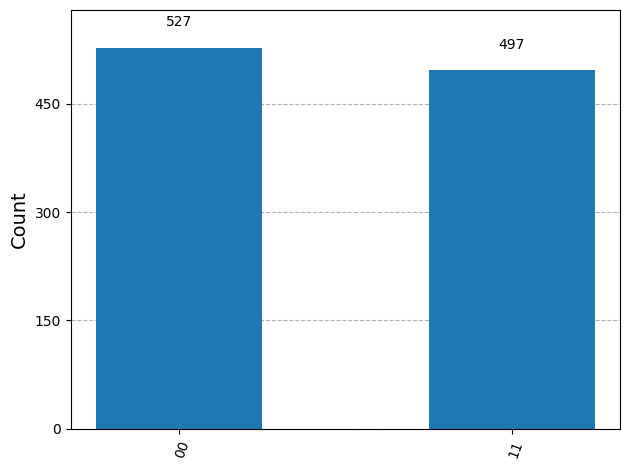

In [30]:
# We expect approximately 50% '00' and 50% '11'.
counts = run_sampling_circuit(measured_qc, shots=1024)
print(counts)
plot_histogram(counts)

## 11. Summary

Key ideas:

1. `QuantumCircuit(1)` creates one qubit and no classical bit.
2. `QuantumCircuit(1, 1)` creates one qubit and one classical bit.
3. Measurement requires classical bits.
4. `compose()` can copy one circuit into another circuit.
5. `shots` means repeating the experiment many times.
6. The $H$ gate creates superposition.
7. The $CX$ / CNOT gate can create entanglement when applied after superposition.
8. Statevectors show the exact quantum state before measurement.
9. Histograms show sampled measurement results after repeated shots.
10. In this notebook, Dirac notation is the bit ordering convention: $|q_0 q_1\rangle$.
11. Qiskit output may display bit strings in the reversed order: $|q_1 q_0\rangle$.

Compact slogan:

> Statevector tells us what the quantum state **is**.  
> Measurement tells us what classical result we **observe**.